<a href="https://colab.research.google.com/github/Bunty-Bot/deep_learning_MBFProject/blob/main/DL_RealData_MBFProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing all the required libraries
import os
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
from torch.utils.data import RandomSampler
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
import copy

In [2]:
# Cloning the git repository with the Data
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 8.74 MiB/s, done.


#Data Loading

In [3]:
go_file = "GO_3A0055085.annotprot"
expr5T_file = "expr5Tseq_filtGO_100-1000.lis"

print("First 5 entries from GO file:")
with open(go_file, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

print("\nFirst 5 entries from expr5T file:")
with open(expr5T_file, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

First 5 entries from GO file:
ENSG00000003989.12_SLC7A2
ENSG00000005249.8_PRKAR2B
ENSG00000006071.7_ABCC8
ENSG00000008283.11_CYB561
ENSG00000010379.11_SLC6A13

First 5 entries from expr5T file:
ENSG00000000003.10_TSPAN6	MASPSRRLQTKPVITCFKSVLLIYTFIFWITGVILLAVGIWGKVSLENYFSLLNEKATNVPFVLIATGTVIILLGTFGCFATCRASAWMLKLYAMFLTLVFLVELVAAIVGFVFRHEIKNSFKNNYEKALKQYNSTGDYRSHAVDKIQNTLHCCGVTDYRDWTDTNYYSEKGFPKSCCKLEDCTPQRDADKVNNEGCFIKVMTIIESEMGVVAGISFGVACFQLIGIFLAYCLSRAITNNQYEIV
ENSG00000000419.8_DPM1	XASLEVSRSPRRSRRELEVRSPRQNKYSVLLPTYNERENLPLIVWLLVKSFSESGINYEIIIIDDGSPDGTRDVAEQLEKIYGSDRILLRPREKKLGLGTAYIHGMKHATGNYIIIMDADLSHHPKFIPEFIRKQKEGNFDIVSGTRYKGNGGVYGWDLKRKIISDGVLPCCPGWSLLGSSDPAILASWDYRCEPPRLASRGANFLTQILLRPGASDLTGSFRLYRKEVLEKLIEKCVSKGYVFQMEMIVRARQLNYTIGEVPISFVDRVYGESKLGGNEIVSFLKGLLTLFATT
ENSG00000000938.8_FGR	MGCVFCKKLEPVATAKEDAGLEGDFRSYGAADHYGPDPTKARPASSFAHIPNYSNFSSQAINPGFLDSGTIRGVSGIGVTLFIALYDYEARTEDDLTFTKGEKFHILNNTEGDWWEARSLSSGKTGCIPSNYVAPVDSIQAEEWYFGKIGRKDAERQLLSPGNPQGAFLIRESETTKGAYSLSIRDWDQTRGD

In [4]:
def read_go(seqfile, annotfile):
    """
    Read human protein sequences and one GO term annotation.

    seqfile   : expr5Tseq_filtGO_100-1000.lis (one sequence per line)
    annotfile : e.g. GO0005739.annotprot (one positive protein ID per line)

    Returns sequences (list[str]) and labels (list[int]), same format as read().
    """
    seq_dict = {}
    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) < 2:
                continue
            pid, seq = parts[0], parts[1]
            seq_dict[pid] = seq

    pos_ids = set()
    with open(annotfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    sequences, labels = [], []
    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    print(f"Total sequences: {len(sequences)}, Positives: {sum(labels)}, Negatives: {len(labels)-sum(labels)}")
    return sequences, labels

In [5]:
# The 5 GO terms we need to predict, and their annotation files
# Fixed filenames to match the actual files in the repository (added _3A prefix)
GO_TERMS = {
    "GO:0005739": "GO_3A0005739.annotprot",  # mitochondrion
    "GO:0007165": "GO_3A0007165.annotprot",  # signal transduction
    "GO:0005576": "GO_3A0005576.annotprot",  # extracellular region
    "GO:0055085": "GO_3A0055085.annotprot",  # transmembrane transport
    "GO:0043066": "GO_3A0043066.annotprot",  # neg. regulation of apoptotic process
}

HUMAN_SEQFILE = "expr5Tseq_filtGO_100-1000.lis"

# print class balance for each GO term
for go_id, annotfile in GO_TERMS.items():
    try:
        seqs, labs = read_go(HUMAN_SEQFILE, annotfile)
        print(f"  {go_id}: {sum(labs)} pos / {len(labs)-sum(labs)} neg")
    except FileNotFoundError as e:
        print(f"  Error loading {go_id}: {e}")

Total sequences: 6784, Positives: 472, Negatives: 6312
  GO:0005739: 472 pos / 6312 neg
Total sequences: 6784, Positives: 420, Negatives: 6364
  GO:0007165: 420 pos / 6364 neg
Total sequences: 6784, Positives: 307, Negatives: 6477
  GO:0005576: 307 pos / 6477 neg
Total sequences: 6784, Positives: 226, Negatives: 6558
  GO:0055085: 226 pos / 6558 neg
Total sequences: 6784, Positives: 190, Negatives: 6594
  GO:0043066: 190 pos / 6594 neg


#Balancing the Imabalanced dataset

### Weighted Binary Cross-Entropy Loss for Imbalanced Datasets


In [8]:
go_term_pos_weights = {}

print("Calculating pos_weight for all GO terms:")
for go_id, annotfile in GO_TERMS.items():
    try:
        # Read the sequences and labels for this GO term
        seqs, labels = read_go(HUMAN_SEQFILE, annotfile)

        num_pos_samples = sum(labels)
        num_neg_samples = len(labels) - num_pos_samples

        if num_pos_samples > 0:
            # Calculate pos_weight and store it
            calculated_pos_weight = torch.tensor(num_neg_samples / num_pos_samples, dtype=torch.float)
            go_term_pos_weights[go_id] = calculated_pos_weight
            print(f"  {go_id}: Positives: {num_pos_samples}, Negatives: {num_neg_samples}, Calculated pos_weight: {calculated_pos_weight.item():.2f}")
        else:
            print(f"  {go_id}: No positive samples found, pos_weight cannot be calculated in this manner and will not be stored.")
            go_term_pos_weights[go_id] = torch.tensor(1.0, dtype=torch.float) # Default to 1 if no positive samples

    except FileNotFoundError as e:
        print(f"  Error loading {go_id}: {e}")

print("\nAll GO term positive weights calculated and stored.")
# print(go_term_pos_weights)

Calculating pos_weight for all GO terms:
Total sequences: 6784, Positives: 472, Negatives: 6312
  GO:0005739: Positives: 472, Negatives: 6312, Calculated pos_weight: 13.37
Total sequences: 6784, Positives: 420, Negatives: 6364
  GO:0007165: Positives: 420, Negatives: 6364, Calculated pos_weight: 15.15
Total sequences: 6784, Positives: 307, Negatives: 6477
  GO:0005576: Positives: 307, Negatives: 6477, Calculated pos_weight: 21.10
Total sequences: 6784, Positives: 226, Negatives: 6558
  GO:0055085: Positives: 226, Negatives: 6558, Calculated pos_weight: 29.02
Total sequences: 6784, Positives: 190, Negatives: 6594
  GO:0043066: Positives: 190, Negatives: 6594, Calculated pos_weight: 34.71

All GO term positive weights calculated and stored.


#Data Preprocessing

In [19]:
def generate_train_val_test(datalist, labellist, random_state=42):
    """
    Split data into train, validation, and test sets using a 70/15/15 split.

    Args:
        datalist: List of sequences.
        labellist (list): List of binary labels.
        random_state (int): Seed for reproducibility.

    Returns:
        train_seq, train_lab, val_seq, val_lab, test_seq, test_lab
    """
    if len(datalist) != len(labellist):
        raise ValueError("datalist and labellist must have the same length")
    if len(datalist) == 0:
        raise ValueError("Input data is empty")

    # Step 1: split train (70%) vs temp (30%)
    seq_train, seq_temp, lab_train, lab_temp = train_test_split(
        datalist, labellist,
        test_size=0.30,
        random_state=random_state,
        stratify=labellist
    )

    # Step 2: split temp 50/50 → 15% val, 15% test
    seq_val, seq_test, lab_val, lab_test = train_test_split(
        seq_temp, lab_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=lab_temp
    )

    # Print exact counts
    print(f"Train: {len(seq_train)} sequences, {sum(lab_train)} positive")
    print(f"Val  : {len(seq_val)} sequences, {sum(lab_val)} positive")
    print(f"Test : {len(seq_test)} sequences, {sum(lab_test)} positive")
    print(f"Total: {len(datalist)} sequences")

    return seq_train, lab_train, seq_val, lab_val, seq_test, lab_test

In [20]:
class CNN1D_OneHot(nn.Module):
    def __init__(self, context_size, conv_channels=128, use_bias=False, dropout=0.0):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(20, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),

            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),

            nn.Flatten(1, -1),
            nn.Linear(int(conv_channels * context_size / 4), 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = X.transpose(1, 2)   # (batch, 20, context_size)
        logits = self.cnn(x).squeeze(1)

        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())

        return logits, loss

In [21]:
class SequenceDatasetOneHot(TensorDataset):
    vocab_size = 20
    padding_token = 20

    def __init__(self, sequences, labels, context_size=200):
        self.context_size = context_size
        self.X = torch.tensor(self.tokenize_onehot(sequences, context_size), dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def tokenize_onehot(self, datalist, max_length=200):
        aa_list = "ACDEFGHIKLMNPQRSTVWY"
        aa_map = {aa: i for i, aa in enumerate(aa_list)}
        encoded = []

        for sequence in datalist:
            row = [[0] * 20 for _ in range(max_length)]
            for i, aa in enumerate(sequence[:max_length]):
                if aa in aa_map:
                    row[i][aa_map[aa]] = 1
            encoded.append(row)

        return encoded

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [24]:
# We reuse everything from before, just adding pos_weight to handle
# the severe class imbalance in real data (e.g. 525 positives vs 6259 negatives)

def train_go_model(go_id, annotfile, context_size=1000, batch_size=32, EPOCHS=30, patience=7):
    print(f"\n{'='*60}")
    print(f"Training for {go_id}  ({annotfile})")
    print(f"{'='*60}")
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {DEVICE}")

    # Load data using the new reader — everything else is the same as before
    seqs, labs = read_go(HUMAN_SEQFILE, annotfile)
    seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seqs, labs)

    # Reuse SequenceDatasetOneHot exactly as before
    train_dataset = SequenceDatasetOneHot(seq_train, lab_train, context_size)
    val_dataset   = SequenceDatasetOneHot(seq_val,   lab_val,   context_size)
    test_dataset  = SequenceDatasetOneHot(seq_test,  lab_test,  context_size)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size)

    # Reuse CNN1D_OneHot — it auto-selects 3 conv blocks for context_size > 200
    model = CNN1D_OneHot(context_size=context_size, conv_channels=64, dropout=0.5).to(DEVICE)

    # Weighted loss: tells the model to care more about the rare positive class
    n_neg = lab_train.count(0)
    n_pos = lab_train.count(1)
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"  pos_weight = {pos_weight.item():.2f}  (n_neg={n_neg}, n_pos={n_pos})")

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(EPOCHS):
        model.train()
        train_epoch = []
        for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(x)                          # get logits
            loss = criterion(logits, y.float())            # weighted loss
            loss.backward()
            optimizer.step()
            train_epoch.append(loss.item())

        model.eval()
        val_epoch = []
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits, _ = model(x)
                val_loss = criterion(logits, y.float())
                val_epoch.append(val_loss.item())

        avg_train = np.mean(train_epoch)
        avg_val   = np.mean(val_epoch)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        print(f"  Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")
        scheduler.step(avg_val)

        if avg_val < best_val_loss - 1e-4:
            best_val_loss = avg_val
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("  Early stopping.")
                break

    model.load_state_dict(best_state)


    plt.plot(train_losses, label="train")
    plt.plot(val_losses,   label="val")
    plt.title(go_id)
    plt.legend(); plt.show()

    return model, test_dataset


Training for GO:0005739  (GO_3A0005739.annotprot)
Using device: cpu
Total sequences: 6784, Positives: 472, Negatives: 6312
Train: 4748 sequences, 330 positive
Val  : 1018 sequences, 71 positive
Test : 1018 sequences, 71 positive
Total: 6784 sequences
  pos_weight = 13.39  (n_neg=4418, n_pos=330)


  Epoch 1: train=1.2909, val=1.2789


  Epoch 2: train=1.2390, val=1.2373


  Epoch 3: train=1.0994, val=1.1707


  Epoch 4: train=0.9597, val=1.1546


...

  Epoch 8: train=0.6318, val=1.2773


  Epoch 9: train=0.5759, val=1.1901


  Epoch 10: train=0.4924, val=1.2966


  Epoch 11: train=0.4318, val=1.2348


  Epoch 12: train=0.4111, val=1.2947
  Early stopping.


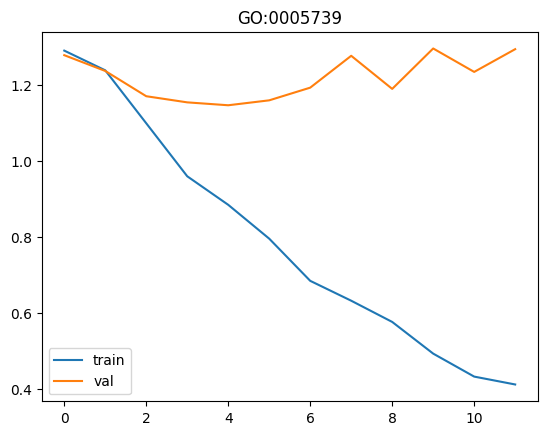


Training for GO:0007165  (GO_3A0007165.annotprot)
Using device: cpu
Total sequences: 6784, Positives: 420, Negatives: 6364
Train: 4748 sequences, 294 positive
Val  : 1018 sequences, 63 positive
Test : 1018 sequences, 63 positive
Total: 6784 sequences
  pos_weight = 15.15  (n_neg=4454, n_pos=294)


  Epoch 1: train=1.3063, val=1.2965


  Epoch 2: train=1.2940, val=1.2941


  Epoch 3: train=1.2829, val=1.2915


  Epoch 4: train=1.2353, val=1.2960


...

  Epoch 8: train=0.8239, val=1.6782


  Epoch 9: train=0.7331, val=1.5389


  Epoch 10: train=0.6095, val=1.7451


  Epoch 11: train=0.5723, val=1.6651


  Epoch 12: train=0.5322, val=1.7507
  Early stopping.


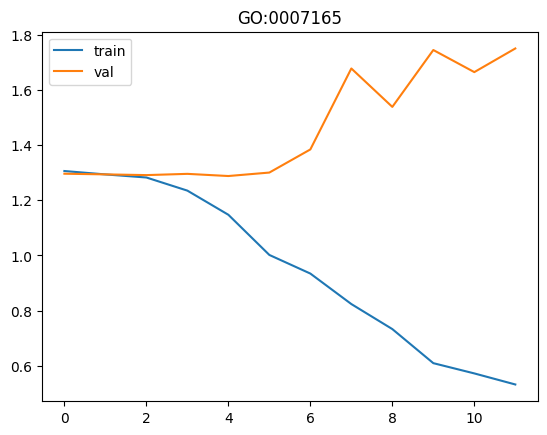


Training for GO:0005576  (GO_3A0005576.annotprot)
Using device: cpu
Total sequences: 6784, Positives: 307, Negatives: 6477
Train: 4748 sequences, 215 positive
Val  : 1018 sequences, 46 positive
Test : 1018 sequences, 46 positive
Total: 6784 sequences
  pos_weight = 21.08  (n_neg=4533, n_pos=215)


  Epoch 1: train=1.3180, val=1.2744


  Epoch 2: train=1.1031, val=1.0308


  Epoch 3: train=0.8949, val=0.9800


  Epoch 4: train=0.7956, val=0.9600


...

  Epoch 7: train=0.5764, val=1.0640


  Epoch 8: train=0.5361, val=1.0806


  Epoch 9: train=0.4356, val=1.1078


  Epoch 10: train=0.4173, val=1.1220


  Epoch 11: train=0.3571, val=1.2057
  Early stopping.


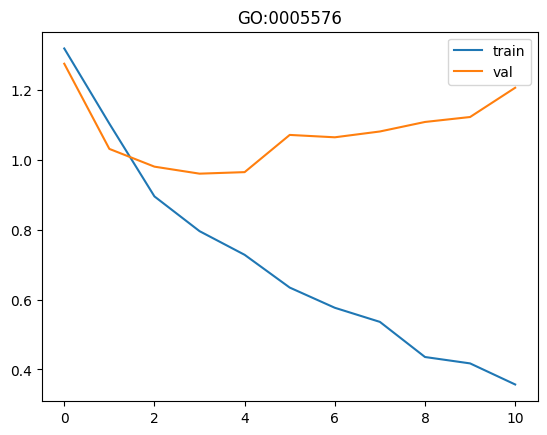


Training for GO:0055085  (GO_3A0055085.annotprot)
Using device: cpu
Total sequences: 6784, Positives: 226, Negatives: 6558
Train: 4748 sequences, 158 positive
Val  : 1018 sequences, 34 positive
Test : 1018 sequences, 34 positive
Total: 6784 sequences
  pos_weight = 29.05  (n_neg=4590, n_pos=158)


  Epoch 1: train=1.3315, val=1.3165


  Epoch 2: train=1.1990, val=1.1429


  Epoch 3: train=0.9720, val=1.0882


  Epoch 4: train=0.9468, val=1.0416


...

  Epoch 7: train=0.6958, val=1.0841


  Epoch 8: train=0.6339, val=1.2973


  Epoch 9: train=0.5565, val=1.3417


  Epoch 10: train=0.4734, val=1.4657


  Epoch 11: train=0.4356, val=1.4655
  Early stopping.


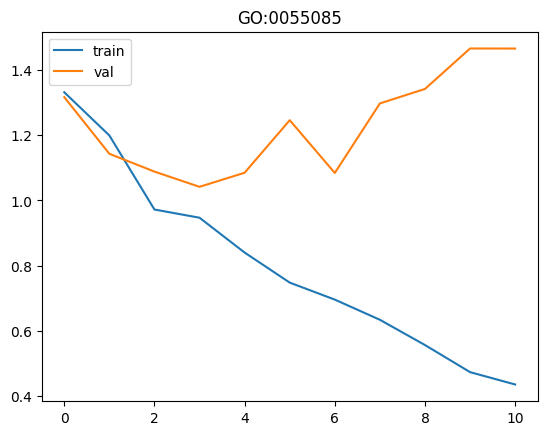


Training for GO:0043066  (GO_3A0043066.annotprot)
Using device: cpu
Total sequences: 6784, Positives: 190, Negatives: 6594
Train: 4748 sequences, 133 positive
Val  : 1018 sequences, 29 positive
Test : 1018 sequences, 28 positive
Total: 6784 sequences
  pos_weight = 34.70  (n_neg=4615, n_pos=133)


  Epoch 1: train=1.4304, val=1.3569


  Epoch 2: train=1.3369, val=1.3561


  Epoch 3: train=1.3401, val=1.3563


  Epoch 4: train=1.3131, val=1.3520


...

  Epoch 8: train=0.9817, val=1.3543


  Epoch 9: train=0.8940, val=1.5790


  Epoch 10: train=0.7369, val=1.4818


  Epoch 11: train=0.6677, val=1.7681


  Epoch 12: train=0.5969, val=1.8686
  Early stopping.


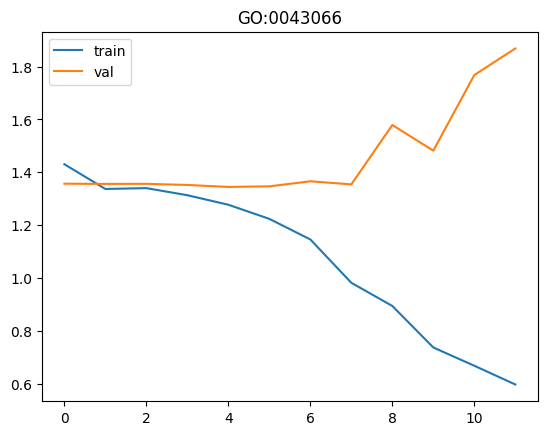

In [25]:
go_models = {}

for go_id, annotfile in GO_TERMS.items():
    model, test_ds = train_go_model(go_id, annotfile)
    go_models[go_id] = (model, test_ds)

In [17]:
# def evaluate_accuracy(model, dataset, name, device):
#     model.eval()
#     all_preds  = []
#     all_labels = []

#     loader = DataLoader(dataset, batch_size=64)

#     with torch.no_grad():
#         for x, y in loader:
#             x = x.to(device)
#             logits, _ = model(x)
#             preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
#             all_preds.extend(preds)
#             all_labels.extend(y.numpy())

#     acc = accuracy_score(all_labels, all_preds)
#     print(f"\n--- {name} Accuracy: {acc:.4f} ---")
#     print(classification_report(all_labels, all_preds, target_names=['Non-functional', 'Functional']))

# # Run on train, val and test
# evaluate_accuracy(model, train_dataset, "Train", DEVICE)
# evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)
# evaluate_accuracy(model, test_dataset,  "Test", DEVICE)

NameError: name 'model' is not defined